In [122]:
import numpy as np

In [123]:
c=np.array([1,7,3,4,5])
print(c+5)

[ 6 12  8  9 10]


In [4]:
set([i for sublist in a for i in sublist])

TypeError: 'int' object is not iterable

In [17]:
import collections


def flatten(x):
    if isinstance(x, collections.Iterable):
        return [a for i in x for a in flatten(i)]
    else:
        return [x]


a = [1, 2, 3, [1, [2, 4]]]
out = set(flatten(a))
out

{1, 2, 3, 4}

In [16]:
def flatten(S):
    if S == []:
        return S
    if isinstance(S[0], list):
        return flatten(S[0]) + flatten(S[1:])
    return S[:1] + flatten(S[1:])

a = [1, 2, 3, [1, [2, 4]]]
out = set(flatten(a))
out

{1, 2, 3, 4}

In [30]:
f = lambda x: [i for i in x]
g = lambda x: f(x) if isinstance(x, list) else x

In [31]:
g(a)

[1, 2, 3, [1, [2, 4]]]

In [18]:
set([num for item in a for num in (item if isinstance(item, list) else (item,))])

TypeError: unhashable type: 'list'

In [34]:
from functools import reduce

In [36]:
newlist = reduce(lambda x,y: x+y, a)

TypeError: unsupported operand type(s) for +: 'int' and 'list'

In [44]:
a

[1, 2, 3, [1, [2, 4]]]

In [ ]:
lambda *n: (e for a in n for e in (flatten(*a) if isinstance(a, (tuple, list)) else (a,)))

In [56]:
f = lambda *n: (e for a in n for e in (f(*a) if isinstance(a, (tuple, list)) else (a,)))

set(f(a))

In [98]:
n = [4, [3,4]]

In [101]:
f = lambda *n: [i for a in n for i in (f(*a) if isinstance(a, (tuple, list)) else (a,))]

In [102]:
f(n)

[4, 3, 4]

In [114]:
a = [5,[3,7]]

In [115]:
(a if isinstance(a, (tuple, list)) else (a,))

[5, [3, 7]]

In [119]:
a = 5

In [120]:
(a if isinstance(a,list) else (a,))

(5,)

In [124]:
import torch
a=torch.randn(3,100)
b=torch.randn(3,100)
row_num = a.size()[0] # 3

# Given two matrix with shape (n1,n2)
# I want to have the row-wise `matmul` results which will result in a tensor with size (n1, ) 

scores = []
for i in range(row_num):
    score_i = a[i,:].matmul(b[i,:])
    scores.append(score_i)
expected_result = torch.tensor(scores)

In [125]:
expected_result

tensor([ 4.8495,  3.3092, -2.7939])

In [130]:
torch.einsum('ij,ij->i',a,b)

tensor([ 4.8495,  3.3092, -2.7939])

In [167]:
torch.diagonal(torch.tensordot(a,b,dims=([1],[1])))

tensor([ 4.8495,  3.3092, -2.7939])

In [168]:
torch.dot(a, b.T)

RuntimeError: 1D tensors expected, but got 2D and 2D tensors

In [171]:
np.diagonal(torch.matmul(a, b.T))

array([ 4.8495054,  3.309207 , -2.7938733], dtype=float32)

In [174]:
np.diagonal(a @ b.T)

array([ 4.8495054,  3.309207 , -2.7938733], dtype=float32)

In [151]:
a.shape

torch.Size([3, 100])

In [152]:
b.shape

torch.Size([3, 100])

tensor([[  4.8495, -13.4082,  -7.3157],
        [ -8.7273,   3.3092,   0.8553],
        [ -6.9103,  14.5447,  -2.7939]])

In [177]:
import pandas as pd

In [182]:
df = pd.read_clipboard()

In [183]:
df

,inventory_partner,inventory_partner2,calc
0,A1,aa,1
1,A2,bb,2
2,A3,cc,5
3,A4,dd,4
4,A5,ee,5
5,A6,ff,3


In [184]:
df.groupby('inventory_partner')

In [53]:
import pandas as pd

bbgDf = pd.DataFrame({'BBG': ['700', 'UNI', 'CSL', 'CSL', 'UNI'],
                        'ID': ['AA','BB','CC','DD','EE'],
                     'TICKER': ['1.hk','2.hk','3.hk','4.hk','5.hk'],
                     'AMOUNT': [100.01,200.45,300.12,400.98,500.45]})

f = lambda x : x.sum() if x.dtype=='float' else ', '.join(x)
g = {'ID':f,'TICKER':f,'AMOUNT':f}

bbgDf = bbgDf.groupby('BBG').agg(g).reset_index()
print(bbgDf)

   BBG      ID      TICKER  AMOUNT
0  700      AA        1.hk  100.01
1  CSL  CC, DD  3.hk, 4.hk  701.10
2  UNI  BB, EE  2.hk, 5.hk  700.90


In [60]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

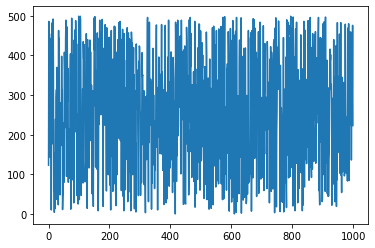

In [63]:
plt.plot(np.random.randint(0,500, (1000,)))

In [ ]:
   ID   A   B   C   Values
0   1   0.0 0   10  10
1   1   2.0 0   0   2
2   1   0.0 0   3   3
3   2   4.0 0   0   4
4   3   0.0 9   0   9
5   3   0.0 3   0   3
6   4   4.0 0   0   4
7   5   0.0 0   0   5
8   6   NaN 0   2   2
9   7   0.0 0   3   3

In [103]:
import pandas as pd
df = pd.DataFrame({'ID': [1,1,1,2,3,3,4,5,6,7], 
                   'A': [0,1,0,1,0,0,1,0,np.nan,0],
                   'B': [0,0,0,0,1,1,0,0,0,0],
                   'C': [1,0,1,0,0,0,0,0,1,1],
                   'Values': [10, 2, 3,4,9,3,4,5,2,3]})

array([[False, False,  True],
       [ True, False, False],
       [False, False,  True],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [False, False, False],
       [False, False,  True],
       [False, False,  True]])

In [78]:
df['A'] = df['A']*df['Values']
df['B'] = df['B']*df['Values']
df['C'] = df['C']*df['Values']

print(df)

   ID    A  B   C  Values
0   1  0.0  0  10      10
1   1  2.0  0   0       2
2   1  0.0  0   3       3
3   2  4.0  0   0       4
4   3  0.0  9   0       9
5   3  0.0  3   0       3
6   4  4.0  0   0       4
7   5  0.0  0   0       5
8   6  NaN  0   2       2
9   7  0.0  0   3       3


In [88]:
df['Values']df['A'].eq(1)

0    False
1     True
2    False
3     True
4    False
5    False
6     True
7    False
8    False
9    False
Name: A, dtype: bool

In [135]:
ind=[[1,2,3,4],[1,2,3,4],[1,2,3,4],[1,2,3,4],[1,2,3,4],[1,2,3,4]]
col=['Example', 'Example', 'Example', 'Example']
pd.DataFrame(np.zeros((6,4)), columns = col, index=pd.MultiIndex.from_tuples(ind))

Example  Example  Example  Example
1 2 3 4      0.0      0.0      0.0      0.0
      4      0.0      0.0      0.0      0.0
      4      0.0      0.0      0.0      0.0
      4      0.0      0.0      0.0      0.0
      4      0.0      0.0      0.0      0.0
      4      0.0      0.0      0.0      0.0

In [133]:
pd.MultiIndex.from_tuples(ind)

MultiIndex([(1, 2, 3, 4),
            (1, 2, 3, 4),
            (1, 2, 3, 4),
            (1, 2, 3, 4),
            (1, 2, 3, 4),
            (1, 2, 3, 4)],
           )

In [154]:
get_percent = lambda x,y: (0.2)*x

200.0

0.25

In [152]:


0.4*1000/2

200.0

In [161]:
from sklearn.model_selection import train_test_split

X, y = np.random.random((1000,10)), np.random.random((1000,))

p = 0.2
new_p = (p*y.shape[0])/((1-p)*y.shape[0])

X, X_val, y, y_val = train_test_split(X, y, test_size=p)
X_train, X_test, y, y_test = train_test_split(X, y, test_size=new_p)

print([i.shape for i in [X_train, X_test, X_val]])

[(600, 10), (200, 10), (200, 10)]


In [163]:
df = pd.read_clipboard(sep='\s*\|\s*').iloc[1:,1:-1]
df

,ID,details
1,1,"list('name' = 'Something', 'description' = 'Wh..."
2,2,"list('name' = 'Something Else', 'description' ..."


In [181]:
df = pd.DataFrame({'ID':[1,2],
                  'details':[{'name' : 'Something', 'description' : 'What something is'},
                             {'name' : 'Something Else', 'description' : 'Another description'}]})

type(df.details.iloc[0])
## dict

df[['details_name','details_description']] = df.details.apply(pd.Series)

print(df.drop('details', axis=1))

   ID    details_name  details_description
0   1       Something    What something is
1   2  Something Else  Another description


,name,description
0,Something,What something is
1,Something Else,Another description


In [184]:
import os
import sys
import numpy as np
import re

lines = ['>=2 1 2 3', '>=3 1 2 3', '>=2 1 2 3']

p=1
#sys.stdout = open("results.txt", "w")
for i in list(lines):
    if i[0] != '<' and i[0] != '>' and i[0] != '=':# change txt file for np.array
        p = str(' '.join(i.split())) 
        print(p)
        
    else:
        w = i[3:]
        frst=i[2]
        w = ', '.join(w.split())
        y = i[2]
        y=int(y)+1
        #INSERT input to array
        c=np.array([w])
        c1 = [int(i) for i in c[0].replace(" ", "").split(",")]

        frst=str(frst).replace("[",'')
        frst=str(frst).replace("]",'')
        frst=int(frst)
        c1=np.array(c1)        

        sest2=c1
        c1=np.array([c1]*frst) #frst is the first value by which the matrix is multiplied
        c1=np.transpose(c1)#transpose
        

        #change value every iteration
        c1=c1 + 10 * (np.arange(c1.shape[1]) + 1)*p
        left=c1*-1
        sedem=np.transpose(left)*-1 #transpose matrix
        p +=1
       
        #editing outputs
        sedem=str(sedem).replace("[",'')
        sedem=str(sedem).replace("]",' 0')
        sedem=str(sedem).replace(".",'')
        sedem = sedem[:-1]
        sedem=str(sedem).replace("\n ",'\n')
        sedem=str(sedem).replace("  ",' ')
        sedem=str(sedem).replace("\n ",'\n')
        sedem=str(sedem).lstrip()       
        print(sedem,'\n')

11 12 13 0
21 22 23 0  

21 22 23 0
41 42 43 0
61 62 63 0  

31 32 33 0
61 62 63 0  



In [186]:
arr = np.array([[2,1,2,3],[3,1,2,3],[2,1,2,3]])

In [190]:
arr[:,0]

array([2, 3, 2])

In [194]:
arr[:,0]*arr[:,1:]

array([[2, 6, 6],
       [2, 6, 6],
       [2, 6, 6]])

In [199]:
arr[:,0]*10

array([20, 30, 20])

In [270]:
#Setup each row in text file as a row in a np matrix

arr = np.array([[2,1,2,3],
                [3,1,2,3],
                [2,1,2,3]])

print('INPUT:')
print(arr)
print('')

ones = np.repeat(arr[:,1:], arr[:,0], axis=0)
tens = (np.arange(1,arr[:,0].sum()+1)*10)
nums = ones+tens[:, None]

print('nums:')
print(nums)
print('')

#Splitting nums for each input
l = np.cumsum([0]+list(arr[:,0]))
chunks = [nums[i:j,:] for i,j in zip(l,l[1:])]

print('OUTPUT:')
for i,chunk in enumerate(chunks):
    print('chunk number',i,':')
    print(chunk)
    print('')
    
INPUT:
[[2 1 2 3]
 [3 1 2 3]
 [2 1 2 3]]

nums:
[[11 12 13]
 [21 22 23]
 [31 32 33]
 [41 42 43]
 [51 52 53]
 [61 62 63]
 [71 72 73]]

OUTPUT:
chunk number 0 :
[[11 12 13]
 [21 22 23]]

chunk number 1 :
[[31 32 33]
 [41 42 43]
 [51 52 53]]

chunk number 2 :
[[61 62 63]
 [71 72 73]]

INPUT:
[[2 1 2 3]
 [3 1 2 3]
 [2 1 2 3]]

nums:
[[11 12 13]
 [21 22 23]
 [31 32 33]
 [41 42 43]
 [51 52 53]
 [61 62 63]
 [71 72 73]]

OUTPUT:
chunk number 0 :
[[11 12 13]
 [21 22 23]]

chunk number 1 :
[[31 32 33]
 [41 42 43]
 [51 52 53]]

chunk number 2 :
[[61 62 63]
 [71 72 73]]



In [254]:
[i for i in ]

SyntaxError: invalid syntax (<ipython-input-254-2b2b023bcd64>, line 1)

In [272]:
import tensorflow as tf

In [309]:
x

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[7, 2, 3],
       [5, 0, 1],
       [7, 8, 2]], dtype=int32)>

In [310]:
tf.argmax(x, axis=1)

<tf.Tensor: shape=(3,), dtype=int64, numpy=array([0, 0, 1])>

In [311]:
tf.sparse.mask(x, tf.argmax(x, axis=1))

AttributeError: 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'indices'

In [321]:
x = tf.constant([[7, 2, 3], 
                 [5, 0, 5], 
                 [7, 8, 7]])

tf.where(x==tf.reduce_max(x, axis=1, keepdims=True), 1,0)

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[1, 0, 0],
       [1, 0, 1],
       [0, 1, 0]], dtype=int32)>

In [340]:
tf.maximum(x, axis=1, keepdims=1) == x

TypeError: maximum() got an unexpected keyword argument 'axis'

In [341]:
tf.math.maximum()

TypeError: maximum() got an unexpected keyword argument 'axis'

In [375]:
tf.cast(tf.equal(tf.argsort(tf.argsort(x, 1,), 1), x.shape[0]-1), tf.int64)

<tf.Tensor: shape=(3, 3), dtype=int64, numpy=
array([[1, 0, 0],
       [0, 0, 1],
       [0, 1, 0]])>

In [397]:
L=[16, 5, 14, 7, 21, 9, 14, 19, 27, 1, 18, 5,27, 15, 14, 5, 27, 20, 15, 27, 15, 14, 5]

L2 = L+[27]*(3-len(L)%3) #Append list
n = int(len(L2)/3)       #Get number of cols
L3 = [L2[i:i+n] for i in range(0,len(L2),n)] #chunk list
L3

[[16, 5, 14, 7, 21, 9, 14, 19],
 [27, 1, 18, 5, 27, 15, 14, 5],
 [27, 20, 15, 27, 15, 14, 5, 27]]

[[16, 5, 14, 7, 21, 9, 14, 19],
 [27, 1, 18, 5, 27, 15, 14, 5],
 [27, 20, 15, 27, 15, 14, 5, 27]]